In [1]:
import os 

In [2]:
data = "datas\\names.txt" 
data_path = os.path.join(os.getcwd(),data)

In [3]:
#%pwd  ==>> for viewing current directory
#os.chdir("../") ==>> leaving current directory 

In [4]:
text_data = open(data_path,"r").read().splitlines()
type(text_data)

list

In [5]:
len(text_data),type(text_data)

(32033, list)

In [6]:
## lets check which is name is min and max character in the name of list 

print(f"min character name = {min(text_data, key= len)}:{len(min(text_data,key=len))} \nmax character name = {max(text_data,key=len)}: {len(max(text_data,key=len))}")

min character name = an:2 
max character name = muhammadibrahim: 15


## Bigram model

In [7]:
big = {}
for word in text_data:
    chars = ["<S>"] + list(word) + ["<E>"]
    for char1,char2 in zip(chars,chars[1:]):
        bigram = (char1,char2)
        big[bigram] = big.get(bigram,0) +1 
        

In [8]:
max(big.items(),key=lambda ky: ky[1])[-1] 

6763

In [9]:
sorted(big.items(),key=lambda ky: ky[1],reverse=True)

# most repeated character combination. first and second character combination

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

Sore this information in 2D array. 
- Raws are going to be first character 
- Column are going to be second character 

Each entry in the 2D arrays tell us about the how often the 2nd character follows the 1st. 

In [10]:
import torch 

In [21]:
chars= sorted(list(set("".join(text_data)) ))
strtoint = {s:i for i,s in enumerate(chars)}
inttostr = {i:s for i,s in enumerate(chars)}

strtoint["<S>"] = 26
strtoint["<E>"] = 27 

inttostr[26] = "<S>"
inttostr[27] = "<E>"
#{i:s for i,s in enumerate(strtoint)}  

In [12]:
# make 26 + 2 (<S> and <E>) 2D-arrays

N = torch.zeros(28,28,dtype=torch.int32)
for word in text_data:
    chars = ["<S>"] + list(word) + ["<E>"]
    for char1,char2 in zip(chars,chars[1:]):
        x_index = strtoint[char1]
        y_index = strtoint[char2]
        N[x_index,y_index] += 1 

Text(0, 0.5, 'second character')

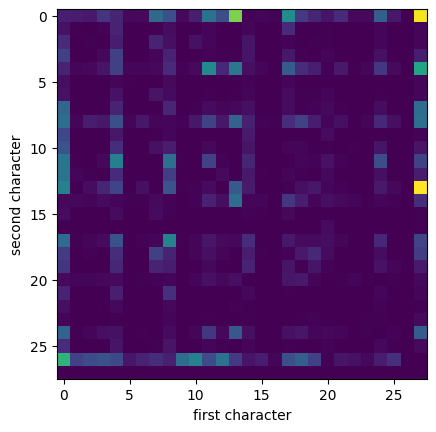

In [13]:
import matplotlib.pyplot as plt

plt.imshow(N) 
plt.xlabel("first character")
plt.ylabel("second character")  

In [14]:
# plot a nice digram showing better understanding or combination of characters (1st and 2nd)
inttostr[1] + inttostr[3] 

'bd'

(-0.5, 27.5, 27.5, -0.5)

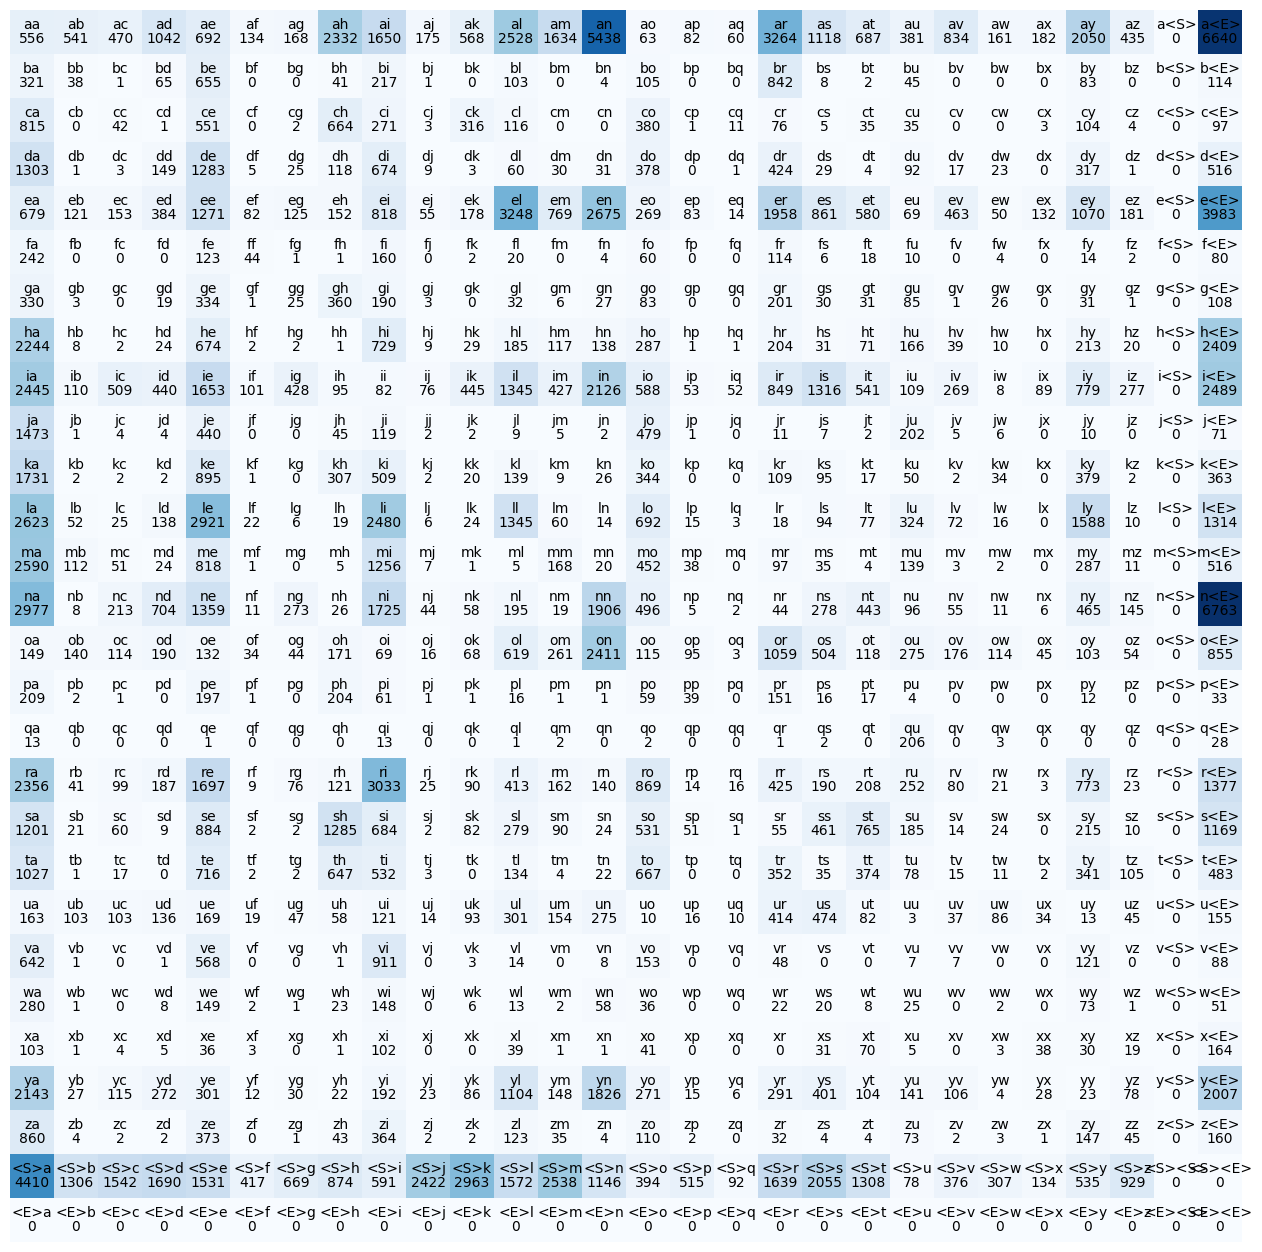

In [15]:

plt.figure(figsize=(16,16))
plt.imshow(N,cmap="Blues")
for i in range(len(inttostr)):
    for j in range(len(inttostr)):
        combination = inttostr[i] + inttostr[j] 
        plt.text(j,i,combination, ha='center', va='bottom', color='black')
        plt.text(j,i,N[i,j].item(), ha='center', va='top', color='black')
plt.axis("off") 

In [86]:
chars   = sorted(list(set("".join(text_data))))
stoi    = {s:i for i,s in enumerate(chars)} 
# replace special tokens with "."
stoi["."] = 26
itos    = {i:s for i,s in stoi.items()}
